#### Problem 1

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)

np.random.seed(123)

p = 0.30
sample_size = 20

# generate 20 Bernoulli observations 
samples = np.random.binomial(n=1, p=p, size=sample_size)
print("Step 3: Generated samples (n=20)")
print(samples)
print("Number of observations generated:", len(samples))

Step 3: Generated samples (n=20)
[0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0]
Number of observations generated: 20


In [19]:
# count clicks / non-clicks 
number_of_clicks = np.sum(samples == 1)
number_of_non_clicks = np.sum(samples == 0)
print("Step 4:")
print("Number of clicks:", number_of_clicks)
print("Number of non-clicks:", number_of_non_clicks)
print("Sum check (should be 20):", number_of_clicks + number_of_non_clicks)
print()

# empirical PMF 
empirical_p1 = number_of_clicks / sample_size
empirical_p0 = number_of_non_clicks / sample_size
print("Step 5: Empirical PMF")
print("Empirical P(X=0) =", empirical_p0)
print("Empirical P(X=1) =", empirical_p1)


Step 4:
Number of clicks: 4
Number of non-clicks: 16
Sum check (should be 20): 20

Step 5: Empirical PMF
Empirical P(X=0) = 0.8
Empirical P(X=1) = 0.2


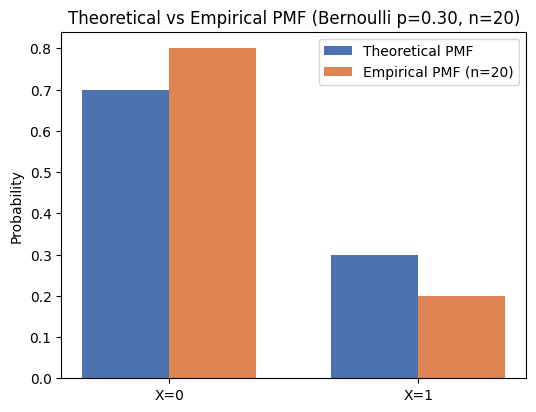

In [34]:
# theoretical PMF
theoretical_p1 = p
theoretical_p0 = 1 - p

# Step 7: plot 
labels = ['X=0', 'X=1']
theo_vals = [theoretical_p0, theoretical_p1]
emp_vals = [empirical_p0, empirical_p1]

x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(6,4.5))
ax.bar(x - width/2, theo_vals, width, label='Theoretical PMF', color='#4C72B0')
ax.bar(x + width/2, emp_vals, width, label='Empirical PMF (n=20)', color='#DD8452')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Probability')
ax.set_title('Theoretical vs Empirical PMF (Bernoulli p=0.30, n=20)')
ax.legend()
plt.show()

In [25]:
# Step 8 & 9: expectation 
theoretical_mean = p
empirical_mean = np.mean(samples)
print("Step 8: Theoretical expectation E[X] =", theoretical_mean)
print("Step 9: Empirical expectation (mean of samples) =", empirical_mean)
print()

#  Step 10 & 11: variance 
theoretical_var = p * (1 - p)
empirical_var = np.var(samples)  # population variance (ddof=0)
print("Step 10: Theoretical variance Var(X) =", theoretical_var)
print("Step 11: Empirical variance =", empirical_var)


Step 8: Theoretical expectation E[X] = 0.3
Step 9: Empirical expectation (mean of samples) = 0.2

Step 10: Theoretical variance Var(X) = 0.21
Step 11: Empirical variance = 0.16000000000000006


In [27]:
# Step 12: final result table 
table = pd.DataFrame({
    "Measure": ["P(X=0)", "P(X=1)", "Expectation", "Variance"],
    "Theoretical value": [theoretical_p0, theoretical_p1, theoretical_mean, theoretical_var],
    "Empirical value": [empirical_p0, empirical_p1, empirical_mean, empirical_var],
})
table["Absolute difference"] = (table["Theoretical value"] - table["Empirical value"]).abs()
print("Step 12: Final Result Table (n=20)")
print(table.to_string())

Step 12: Final Result Table (n=20)
       Measure  Theoretical value  Empirical value  Absolute difference
0       P(X=0)               0.70             0.80                 0.10
1       P(X=1)               0.30             0.20                 0.10
2  Expectation               0.30             0.20                 0.10
3     Variance               0.21             0.16                 0.05


Step 13: Effect of sample size
   Sample size  Empirical P(X=0)  Empirical P(X=1)  Empirical mean  Empirical variance
0           10            0.6000            0.4000          0.4000            0.240000
1          100            0.7000            0.3000          0.3000            0.210000
2         1000            0.6790            0.3210          0.3210            0.217959
3        10000            0.6961            0.3039          0.3039            0.211545


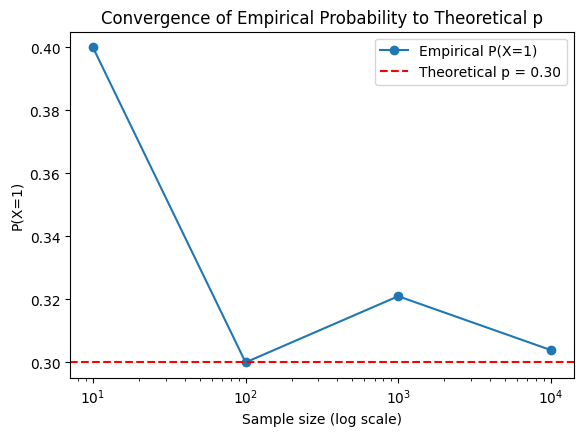

In [35]:
# Step 13: effect of sample size 
sizes = [10, 100, 1000, 10000]
rows = []
for n in sizes:
    s = np.random.binomial(n=1, p=p, size=n)
    p0 = np.mean(s == 0)
    p1 = np.mean(s == 1)
    mean_ = np.mean(s)
    var_ = np.var(s)
    rows.append([n, p0, p1, mean_, var_])

size_table = pd.DataFrame(rows, columns=["Sample size", "Empirical P(X=0)", "Empirical P(X=1)",
                                          "Empirical mean", "Empirical variance"])
print("Step 13: Effect of sample size")
print(size_table.to_string())

# plot convergence of empirical P(X=1) and mean to true p as n grows
fig, ax = plt.subplots(figsize=(6.5,4.5))
ax.plot(size_table["Sample size"], size_table["Empirical P(X=1)"], marker='o', label='Empirical P(X=1)')
ax.axhline(p, color='red', linestyle='--', label='Theoretical p = 0.30')
ax.set_xscale('log')
ax.set_xlabel('Sample size (log scale)')
ax.set_ylabel('P(X=1)')
ax.set_title('Convergence of Empirical Probability to Theoretical p')
ax.legend()
plt.show()

#### Problem 2:


In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom
import pandas as pd

np.random.seed(123)

n = 50          # transactions examined per hour
p = 0.04        # probability a transaction is flagged
n_hours = 20000 # number of simulated one-hour periods
capacity = 4    # max flagged transactions the team can investigate per hour

# Simulate 20,000 independent one-hour periods 
X = np.random.binomial(n=n, p=p, size=n_hours)

print("Simulation summary")
print("Number of simulated hours:", len(X))
print("First 20 simulated hourly counts:", X[:20])

Simulation summary
Number of simulated hours: 20000
First 20 simulated hourly counts: [3 1 1 2 3 2 5 3 2 1 1 3 2 0 1 3 1 1 2 2]


In [40]:
# Empirical distribution
values, counts = np.unique(X, return_counts=True)
empirical_pmf = counts / n_hours

emp_table = pd.DataFrame({
    "X (flagged count)": values,
    "Frequency": counts,
    "Empirical P(X=x)": empirical_pmf,
    "Theoretical P(X=x)": binom.pmf(values, n, p)
})
print("Empirical vs theoretical PMF (values that occurred):")
print(emp_table.to_string())

Empirical vs theoretical PMF (values that occurred):
   X (flagged count)  Frequency  Empirical P(X=x)  Theoretical P(X=x)
0                  0       2598           0.12990            0.129886
1                  1       5353           0.26765            0.270595
2                  2       5619           0.28095            0.276233
3                  3       3713           0.18565            0.184155
4                  4       1743           0.08715            0.090159
5                  5        699           0.03495            0.034561
6                  6        218           0.01090            0.010800
7                  7         44           0.00220            0.002829
8                  8         12           0.00060            0.000634
9                  9          1           0.00005            0.000123


In [41]:
# Empirical mean & variance vs theoretical 
emp_mean = np.mean(X)
emp_var = np.var(X)
theo_mean = n * p
theo_var = n * p * (1 - p)

print(f"Theoretical mean (n*p)            = {theo_mean:.4f}")
print(f"Empirical mean                    = {emp_mean:.4f}")
print(f"Theoretical variance (n*p*(1-p))  = {theo_var:.4f}")
print(f"Empirical variance                = {emp_var:.4f}")


Theoretical mean (n*p)            = 2.0000
Empirical mean                    = 1.9959
Theoretical variance (n*p*(1-p))  = 1.9200
Empirical variance                = 1.8895


In [42]:
#  Probability the investigation team is overwhelmed: P(X > 4) 
emp_overflow = np.mean(X > capacity)
theo_overflow = 1 - binom.cdf(capacity, n, p)
print(f"Empirical  P(X > {capacity})  = {emp_overflow:.4f}  ({emp_overflow*100:.2f}% of hours)")
print(f"Theoretical P(X > {capacity}) = {theo_overflow:.4f}  ({theo_overflow*100:.2f}% of hours)")

Empirical  P(X > 4)  = 0.0487  (4.87% of hours)
Theoretical P(X > 4) = 0.0490  (4.90% of hours)


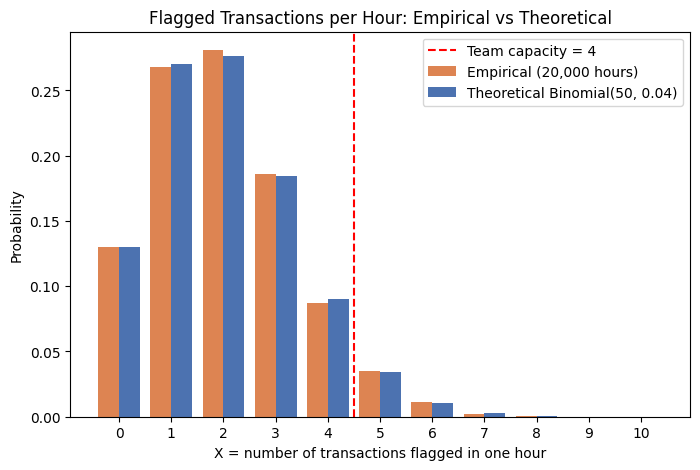

In [43]:
# Plot: empirical histogram vs theoretical PMF 
x_range = np.arange(0, X.max() + 2)
theo_pmf_full = binom.pmf(x_range, n, p)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x_range - 0.2, [np.mean(X == k) for k in x_range], width=0.4,
       label='Empirical (20,000 hours)', color='#DD8452')
ax.bar(x_range + 0.2, theo_pmf_full, width=0.4,
       label='Theoretical Binomial(50, 0.04)', color='#4C72B0')
ax.axvline(capacity + 0.5, color='red', linestyle='--', linewidth=1.5,
           label=f'Team capacity = {capacity}')
ax.set_xlabel('X = number of transactions flagged in one hour')
ax.set_ylabel('Probability')
ax.set_title('Flagged Transactions per Hour: Empirical vs Theoretical')
ax.set_xticks(x_range)
ax.legend()
plt.show()